In [2]:
!pip install pandas

In [3]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

import random

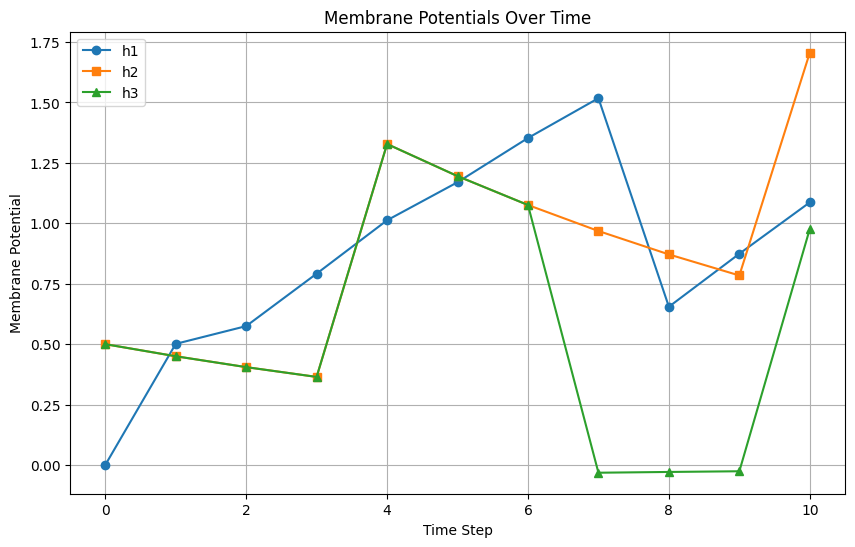

In [4]:
l1 = snn.Leaky(beta=0.9)
l2 = snn.Leaky(beta=0.9)
l3 = snn.Leaky(beta=0.9)

h1 = []
h2 =[]
h3 = []


time_steps = 10
mem1 = torch.zeros(1) 
mem2 = torch.zeros(1) 
mem3 = torch.zeros(1)

x1, mem1 = l1(torch.tensor([0.5]), mem1)
h1.append(x1)
x2, mem2 = l2(x1 + torch.tensor([0.5]), mem2)
h2.append(mem2)
x3, mem3 = l3(x2 + torch.tensor([0.5]), mem3)
h3.append(mem3)
for _ in range(time_steps):
  x1, mem1 = l1(x3[0] + torch.rand(1).clamp(-1, 0.3), mem1)
  h1.append(mem1)
  x2, mem2 = l2(x1, mem2)
  h2.append(mem2)
  x3, mem3 = l3(x2, mem3)
  h3.append(mem3)


plt.figure(figsize=(10, 6))
plt.plot(h1, label='h1', marker='o')
plt.plot(h2, label='h2', marker='s')
plt.plot(h3, label='h3', marker='^')
plt.xlabel('Time Step')
plt.ylabel('Membrane Potential')
plt.title('Membrane Potentials Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
class Neuron(): # need to add __str__ 
    def __init__(self, beta = 0.9):
        self.neuron = snn.Leaky(beta = 0.9)
        self.connections = []
        self.weights = []
        self.history = []
        self.input_spikes = 0.0
        self.spike = 0.0
        self.mem = 0.0

    def add_connection(self, n, weight = 0.7, randomize_weight = True): # Randomize weight overrides the given weight, if any
        self.connections.append(n)
        self.weights.append(np.random.random() if randomize_weight else weight)

    def add_connections(self, n_arr: list):
        for n in n_arr:
            self.add_connection(n)

    def receive_spike(self, input):
        input_spikes += input

    def send_spike(self):
        for i, c in enumerate(connections):
            c.receive_spike(self.spike * weights[i])

    def time_step(self):
        self.spike, self.mem = neuron(self.input_spikes, self.mem)
        history.append(mem)
            

In [41]:
def init_neurons(num:int) -> list:
    neurons = []
    for i in range(num):
        neurons.append(Neuron())
    
    return neurons

def make_connections(neurons: list, num_connections = 1) -> list:
    for neuron in neurons:
        neuron.add_connections(random.sample(neurons, num_connections))


In [42]:
num_neurons = 3
neurons = init_neurons(num_neurons)
make_connections(neurons, num_connections = 2)


In [39]:
do = True
if do:
    print(neurons)
    for i in neurons:
        print(i, i.connections)

[<__main__.Neuron object at 0x7394e197a900>, <__main__.Neuron object at 0x7394e199ccd0>, <__main__.Neuron object at 0x7394e199cb90>]
<__main__.Neuron object at 0x7394e197a900> [<__main__.Neuron object at 0x7394e199cb90>, <__main__.Neuron object at 0x7394e199ccd0>]
<__main__.Neuron object at 0x7394e199ccd0> [<__main__.Neuron object at 0x7394e199cb90>, <__main__.Neuron object at 0x7394e197a900>]
<__main__.Neuron object at 0x7394e199cb90> [<__main__.Neuron object at 0x7394e199ccd0>, <__main__.Neuron object at 0x7394e197a900>]


In [ ]:
time_steps = 20
for _ in time_steps:
    for i, n in enumerate(neurons):
        

[[Leaky(), Leaky()], [Leaky(), Leaky()], [Leaky(), Leaky()]]